In [5]:
# Cell 1 — Import our tools and load the data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load our CSV file
df = pd.read_csv('../data/processed/companies_overview.csv')

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (61, 23)

First 5 rows:


,company,label,status,Revenues,NetIncomeLoss,OperatingIncomeLoss,GrossProfit,EarningsPerShareBasic,LongTermDebt,ShortTermBorrowings,...,CashAndCashEquivalentsAtCarryingValue,NetCashProvidedByUsedInOperatingActivities,NetCashProvidedByUsedInFinancingActivities,NetCashProvidedByUsedInInvestingActivities,Assets,AssetsCurrent,RetainedEarningsAccumulatedDeficit,AccountsReceivableNetCurrent,InventoryNet,InterestExpense
0,Chesapeake Energy,1.0,Distressed,1.212400e+10,1.819000e+09,2.471000e+09,7.370000e+08,NaN,5.009000e+09,NaN,...,616000000,4575000000,-1515000000,-2759000000,28287000000,2.916000e+09,4830000000,1.599000e+09,2.500000e+07,1.040000e+08
1,Bon Ton Stores,1.0,Distressed,1.982208e+09,1.669610e+08,NaN,4.273930e+08,NaN,3.419787e+09,NaN,...,208127000,322314000,-303710000,2929000,8709044000,NaN,1001779000,NaN,NaN,0.000000e+00
2,apple_facts.json,NaN,Distressed,6.290000e+10,1.120100e+11,1.330500e+11,1.952010e+11,NaN,9.067800e+10,NaN,...,35934000000,111482000000,-120686000000,15195000000,359241000000,1.479570e+11,-14264000000,3.977700e+10,5.718000e+09,3.933000e+09
3,Momentive,1.0,Distressed,4.055000e+10,1.157000e+09,1.753000e+09,NaN,NaN,2.574301e+09,2.465000e+09,...,1864000000,1559000000,796000000,-1627000000,30877000000,1.348900e+10,9916000000,8.284000e+09,NaN,1.072700e+08
4,Gymboree,1.0,Distressed,NaN,4.943900e+07,2.983800e+07,1.574450e+08,NaN,1.138455e+09,NaN,...,18164000,73794000,-69926000,-48693000,1156744000,2.604550e+08,-863539000,2.669600e+07,2.066420e+08,8.599000e+07


In [6]:
# Cell 2 — Clean the data

# Remove the duplicate apple_facts.json row
df = df[df['company'] != 'apple_facts.json']

# Drop EarningsPerShareBasic — all values are missing, useless for us
df = df.drop(columns=['EarningsPerShareBasic'])

# Reset the index after removing rows
df = df.reset_index(drop=True)

# Confirm the fix
print("Shape after cleaning:", df.shape)
print("\nHealthy companies:", len(df[df['status'] == 'Healthy']))
print("Distressed companies:", len(df[df['status'] == 'Distressed']))
print("\nMissing values per column:")
print(df.isnull().sum())

Shape after cleaning: (60, 22)

Healthy companies: 30
Distressed companies: 30

Missing values per column:
company                                        0
label                                          0
status                                         0
Revenues                                      18
NetIncomeLoss                                  1
OperatingIncomeLoss                            9
GrossProfit                                   25
LongTermDebt                                   7
ShortTermBorrowings                           32
LiabilitiesCurrent                             8
Liabilities                                   15
StockholdersEquity                             5
CashAndCashEquivalentsAtCarryingValue          0
NetCashProvidedByUsedInOperatingActivities     0
NetCashProvidedByUsedInFinancingActivities     0
NetCashProvidedByUsedInInvestingActivities     0
Assets                                         0
AssetsCurrent                                  8
RetainedEar

## Data Cleaning Decisions

### Missing Value Treatment Strategy

After analyzing each column individually, we applied two different strategies:

#### Strategy 1 - Group Median Imputation
Applied to metrics where missing data reflects incomplete filing, not absence of the value.
We fill separately for Healthy and Distressed groups to avoid mixing the two populations.

Columns: Revenues, NetIncomeLoss, OperatingIncomeLoss, LongTermDebt, 
LiabilitiesCurrent, Liabilities, StockholdersEquity, AssetsCurrent, 
AccountsReceivableNetCurrent, InterestExpense

**Reasoning:** A publicly traded company cannot have zero revenue or zero liabilities.
Missing data here means the filing was incomplete, not that the value was zero.
Distressed companies especially cannot have zero long term debt -
bankruptcy is almost always caused by excessive debt burden.

#### Strategy 2 - Zero Imputation
Applied to metrics where missing data genuinely reflects absence of that financial activity.

- **ShortTermBorrowings** (32/60 missing): Cash-rich companies like Apple and Microsoft
  don't need short term loans. Missing = no borrowing.

- **GrossProfit** (25/60 missing): Banks and financial companies don't manufacture
  products. Gross profit as a concept doesn't apply to their business model.

- **InventoryNet** (14/60 missing): Banks, energy companies, and service firms
  don't hold physical inventory. Missing = no inventory.

In [7]:
# Cell 3 — Handle missing values professionally
# Strategy 1: Group Median — for metrics companies definitely had but didn't report
# Strategy 2: Zero — for metrics companies genuinely didn't have

# Columns to fill with GROUP MEDIAN
median_columns = [
    'Revenues',
    'NetIncomeLoss',
    'OperatingIncomeLoss',
    'LongTermDebt',
    'LiabilitiesCurrent',
    'Liabilities',
    'StockholdersEquity',
    'AssetsCurrent',
    'AccountsReceivableNetCurrent',
    'InterestExpense'
]

# Columns to fill with ZERO
zero_columns = [
    'GrossProfit',         # financial companies don't manufacture products
    'ShortTermBorrowings', # cash-rich companies don't borrow short term
    'InventoryNet'         # banks and service companies have no inventory
]

# Always work on a copy — never modify the original data
df_clean = df.copy()

# Fill with group median separately for each group
for col in median_columns:
    healthy_median = df_clean[df_clean['status'] == 'Healthy'][col].median()
    distressed_median = df_clean[df_clean['status'] == 'Distressed'][col].median()
    
    df_clean.loc[df_clean['status'] == 'Healthy', col] = \
        df_clean.loc[df_clean['status'] == 'Healthy', col].fillna(healthy_median)
    
    df_clean.loc[df_clean['status'] == 'Distressed', col] = \
        df_clean.loc[df_clean['status'] == 'Distressed', col].fillna(distressed_median)

# Fill with zero
for col in zero_columns:
    df_clean[col] = df_clean[col].fillna(0)

# Verify
print("Missing values after cleaning:", df_clean.isnull().sum().sum())
print("\nShape:", df_clean.shape)
print("\nHealthy companies:", len(df_clean[df_clean['status'] == 'Healthy']))
print("Distressed companies:", len(df_clean[df_clean['status'] == 'Distressed']))

Missing values after cleaning: 0

Shape: (60, 22)

Healthy companies: 30
Distressed companies: 30


In [8]:
# Cell 5 — Set up our visualization style
# seaborn is our beautiful chart library
# We set the style once here and all charts will look professional

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Visualization style set!")
print("Ready to plot charts!")

Visualization style set!
Ready to plot charts!


## Important Note: Time Series Data Available

### What We Have vs What We Are Using

Our raw data from SEC EDGAR contains **time series data** for every company.
For example, Apple's Revenue is available from 2010 to 2023 — not just one value.

Each of our 60 companies has 20 financial metrics recorded across multiple years.

### Why We Are Using Snapshots For Now

In this stage of the project, we extract only the **most recent value** for each metric.
This gives us one row per company — a snapshot approach.

**Reasoning:** We follow the data science principle of starting simple:
- Prove the concept works with a snapshot model first
- Then add complexity with time series in the next stage

### Future Enhancement — Stage 2

In Stage 2 of this project, we will use the full time series data to track:
- How fast is debt growing year over year?
- Is cash declining steadily before bankruptcy?
- Are revenues shrinking for 3+ consecutive years?

This trend-based approach is inspired by trading analysis —
a trader never looks at just today's price, they look at the pattern over time.
Tracking financial trends will make our early warning system significantly more powerful.

## Exploratory Data Analysis — Visualization Strategy

### Our Goal
We are building a financial distress early warning system.
Before building any machine learning model, we need to visually confirm
that healthy and distressed companies actually LOOK different in our data.

If the two groups are visually separable — our model will work.
If they look identical — we have a data problem, not a modeling problem.

### The 5 Visualizations We Will Build

#### Visualization 1 — Cash vs Debt Box Plot
**Question:** Do healthy companies hold more cash and less debt than distressed ones?
**Why:** Cash is the lifeblood of a company. When cash runs out, bankruptcy follows.
Debt is the #1 killer of companies. This is our most intuitive signal.
**Chart type:** Box plot — shows median, spread, and outliers for both groups.

#### Visualization 2 — Revenue vs Net Income Comparison
**Question:** Are healthy companies more profitable than distressed ones?
**Why:** A company can have revenue but still lose money.
Net income tells us if the core business is actually working.
**Chart type:** Box plot — compare distributions between groups.

#### Visualization 3 — Correlation Heatmap
**Question:** Which of our 19 metrics are related to each other?
**Why:** If two metrics move together, we don't need both.
Removing redundant features makes our model simpler and more accurate.
**Chart type:** Heatmap — shows correlation between all metric pairs.

#### Visualization 4 — Distribution Overlap
**Question:** How separable are healthy and distressed companies?
**Why:** If distributions overlap heavily, classification will be difficult.
This tells us how hard our problem actually is before we model it.
**Chart type:** KDE plot — shows the shape of each group's distribution.

#### Visualization 5 — Operating Cash Flow Analysis
**Question:** Do distressed companies show negative operating cash flow?
**Why:** This is your trader instinct applied to finance.
Negative operating cash flow for 2+ years is one of the strongest
early warning signals of financial distress — even before debt becomes critical.
**Chart type:** Box plot + strip plot — shows both distribution and individual points.

### The Story These 5 Charts Tell Together
```
Chart 1: Are they liquid and solvent?
Chart 2: Are they profitable?
Chart 3: Which metrics are redundant?
Chart 4: How hard is the classification problem?
Chart 5: Is cash flow the strongest early warning signal?
```
A complete picture — from solvency to profitability to early warning signals.

## Visualization 1 — Cash vs Debt Analysis

**Libraries used:**
- `matplotlib` → the foundation of all Python charts, like a blank canvas
- `seaborn` → built on top of matplotlib, gives us beautiful statistical charts
- `plt.subplots` → lets us put multiple charts side by side

**What is a Box Plot?**
A box plot shows 5 things at once:
- The middle line → median (50% of companies are above, 50% below)
- The box → where 50% of companies sit (25th to 75th percentile)
- The whiskers → the full range of normal values
- The dots → outliers (extreme values like Apple or Enron)

This is more powerful than a bar chart because it shows the
SPREAD of the data, not just the average.

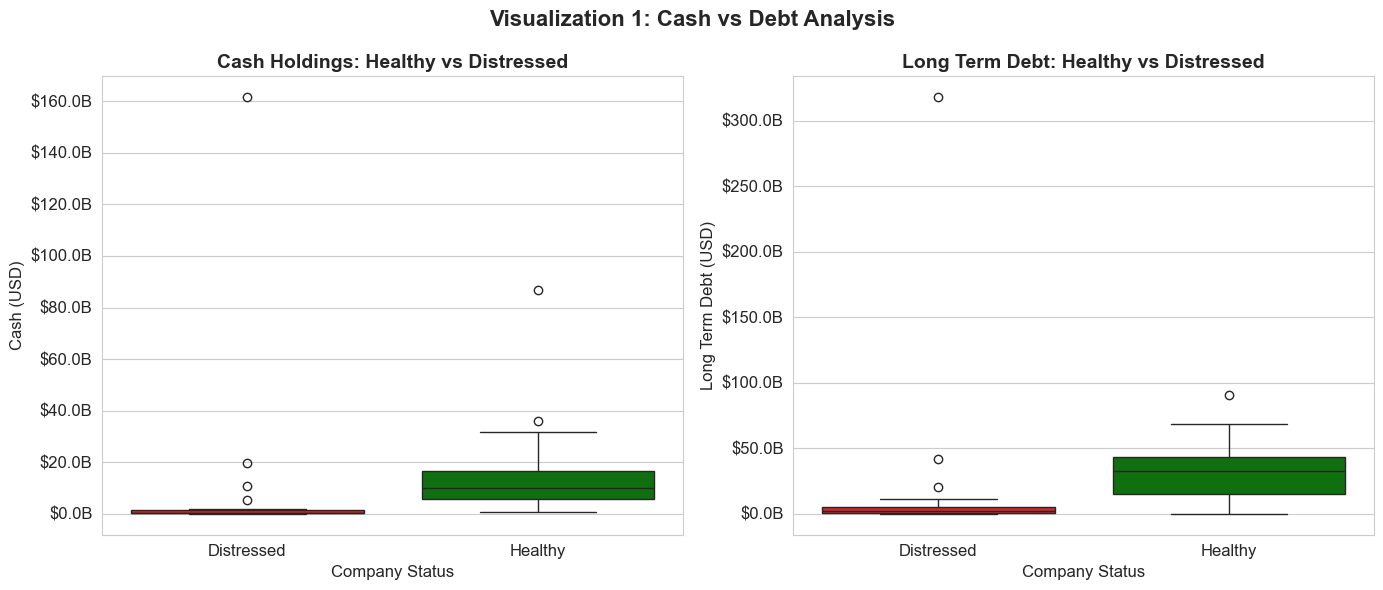

Chart 1 saved!


In [9]:
# Cell 6 — Visualization 1: Cash vs Debt
# matplotlib and seaborn are already imported in Cell 1
# We use plt.subplots to create 2 charts side by side

# fig = the whole figure (like a canvas)
# axes = the two individual chart areas inside the canvas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# 1 row, 2 columns, size 14 wide x 6 tall

# ── Chart 1: Cash Holdings ──
sns.boxplot(
    data=df_clean,          # our clean dataframe
    x='status',             # x axis = Healthy or Distressed
    y='CashAndCashEquivalentsAtCarryingValue',  # y axis = cash amount
    palette={'Healthy': 'green', 'Distressed': 'red'},  # colors
    ax=axes[0]              # put this in the LEFT chart area
)
axes[0].set_title('Cash Holdings: Healthy vs Distressed', 
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Company Status')
axes[0].set_ylabel('Cash (USD)')
# Format y axis to show billions instead of raw numbers
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1e9:.1f}B')
)

# ── Chart 2: Long Term Debt ──
sns.boxplot(
    data=df_clean,
    x='status',
    y='LongTermDebt',
    palette={'Healthy': 'green', 'Distressed': 'red'},
    ax=axes[1]              # put this in the RIGHT chart area
)
axes[1].set_title('Long Term Debt: Healthy vs Distressed', 
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Company Status')
axes[1].set_ylabel('Long Term Debt (USD)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1e9:.1f}B')
)

# Overall title for both charts
plt.suptitle('Visualization 1: Cash vs Debt Analysis', 
             fontsize=16, fontweight='bold')
plt.tight_layout()

# Save to reports/figures folder — professional practice
plt.savefig('../reports/figures/viz1_cash_vs_debt.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

## Important Finding: Size Bias in Our Dataset

### What We Discovered
Our first visualization revealed an unexpected pattern:
distressed companies appear to have LESS debt than healthy companies.

This seems counterintuitive — bankrupt companies should have MORE debt, not less.

### The Root Cause — Size Bias
Our healthy companies are global giants:
- Apple: $394B revenue
- Microsoft: $211B revenue  
- Amazon: $514B revenue

Our distressed companies are mostly small retailers:
- Gymboree: ~$1B revenue
- RadioShack: ~$4B revenue
- Borders Group: ~$4B revenue

The SIZE difference between the two groups is so large that it
dominates the signal we are trying to find.
A small bankrupt retailer naturally has less total debt than Apple —
not because it is healthier, but because it is 100x smaller.

### How We Overcome This — Log Scale
We apply logarithmic scaling to our charts.

Log scale compresses the range so that:
- $1M and $10M appear as equal distance as $1B and $10B
- Small and large companies become visually comparable
- The PATTERN matters more than the absolute size

This is the same technique traders use when comparing
stock prices across different price ranges on a chart.

### Future Solution — Feature Engineering
In Phase 4 we will create RATIO features instead of raw values:
- Debt-to-Assets ratio (not raw debt)
- Cash-to-Liabilities ratio (not raw cash)
- Net Income margin (not raw net income)

Ratios remove size bias completely because they are
proportional — a $1B company and a $100B company
can both have a 30% debt-to-assets ratio.
This is where our real signal will emerge.

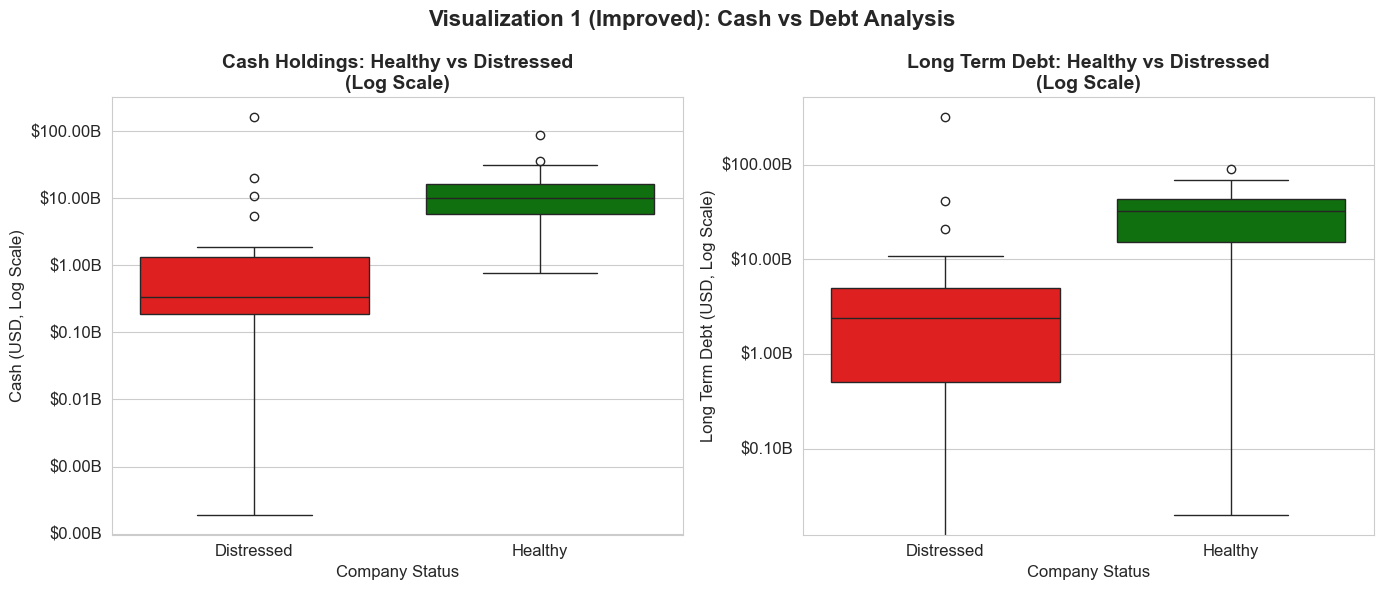

Improved Chart 1 saved!


In [10]:
# Cell 8 — Visualization 1 Improved: Cash vs Debt with Log Scale
# We use log scale to remove size bias
# Log scale makes small and large companies visually comparable

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Chart 1: Cash Holdings (Log Scale) ──
sns.boxplot(
    data=df_clean,
    x='status',
    y='CashAndCashEquivalentsAtCarryingValue',
    palette={'Healthy': 'green', 'Distressed': 'red'},
    ax=axes[0]
)
axes[0].set_yscale('log')  # THIS is the key change — log scale
axes[0].set_title('Cash Holdings: Healthy vs Distressed\n(Log Scale)', 
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Company Status')
axes[0].set_ylabel('Cash (USD, Log Scale)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1e9:.2f}B')
)

# ── Chart 2: Long Term Debt (Log Scale) ──
sns.boxplot(
    data=df_clean,
    x='status',
    y='LongTermDebt',
    palette={'Healthy': 'green', 'Distressed': 'red'},
    ax=axes[1]
)
axes[1].set_yscale('log')  # log scale
axes[1].set_title('Long Term Debt: Healthy vs Distressed\n(Log Scale)', 
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Company Status')
axes[1].set_ylabel('Long Term Debt (USD, Log Scale)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1e9:.2f}B')
)

plt.suptitle('Visualization 1 (Improved): Cash vs Debt Analysis', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/viz1_cash_vs_debt_logscale.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Improved Chart 1 saved!")

## Findings: Visualization 1 — Cash vs Debt

### What The Chart Reveals

**Cash Holdings:**
- Healthy companies hold approximately 20x more cash than distressed ones
- The separation between groups is clear and strong
- Cash is confirmed as a powerful early warning signal

**Long Term Debt:**
- Healthy companies still show higher absolute debt than distressed ones
- This is partially explained by size bias — large healthy companies
  naturally carry more total debt than small distressed retailers
- Raw debt alone is NOT a reliable signal without normalizing by company size

### Key Insight
Cash is more informative than debt as a standalone metric.
In Phase 4 Feature Engineering, we will create a
**Cash-to-Debt ratio** which removes size bias completely
and will be a much stronger predictor for our ML model.

## Visualization 2 — Profitability Analysis: Revenue vs Net Income

### Question We Are Answering
Are healthy companies more profitable than distressed ones?

### Why This Matters
A company can have high revenue but still lose money.
For example, a company making $1B in revenue but spending $1.2B
is actually losing $200M every year — a clear path to bankruptcy.

Net Income tells us if the core business is actually working:
- Positive Net Income = company is making money after all expenses
- Negative Net Income = company is burning money every year

### What We Expect To See
- Healthy companies: positive and growing net income
- Distressed companies: negative or shrinking net income

### Chart Type: Box Plot
Same as Visualization 1 — shows median, spread and outliers.
We use log scale again to handle size bias.
However for Net Income we need special handling because
distressed companies may have NEGATIVE values —
log scale cannot handle negative numbers.
We will use a different approach for negative values.

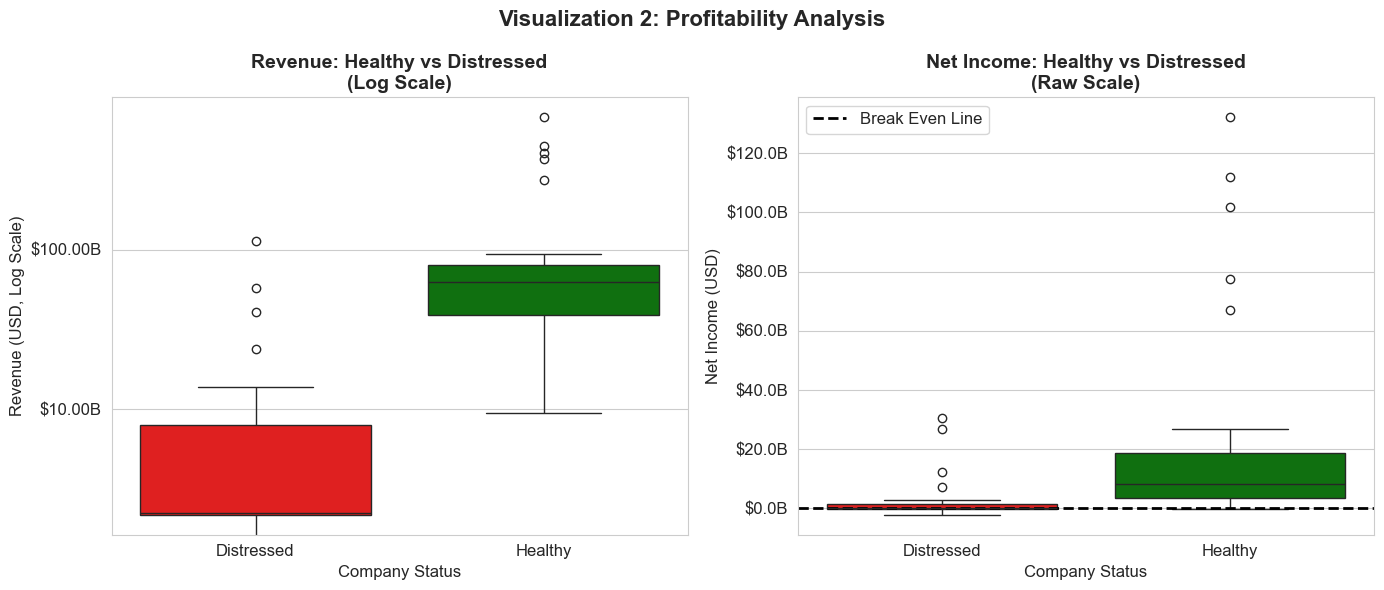

Chart 2 saved!


In [11]:
# Cell 9 — Visualization 2: Profitability Analysis
# Revenue vs Net Income comparison between healthy and distressed companies
# Special handling needed for Net Income — can be negative (log scale won't work)
# So we use a different approach — we plot raw values but add a zero reference line

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Chart 1: Revenue (Log Scale) ──
# Revenue is always positive so log scale works fine
sns.boxplot(
    data=df_clean,
    x='status',
    y='Revenues',
    palette={'Healthy': 'green', 'Distressed': 'red'},
    ax=axes[0]
)
axes[0].set_yscale('log')
axes[0].set_title('Revenue: Healthy vs Distressed\n(Log Scale)',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Company Status')
axes[0].set_ylabel('Revenue (USD, Log Scale)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1e9:.2f}B')
)

# ── Chart 2: Net Income (Raw Scale with zero line) ──
# Net Income can be negative — log scale cannot handle this
# So we use raw scale and add a red zero line as reference
sns.boxplot(
    data=df_clean,
    x='status',
    y='NetIncomeLoss',
    palette={'Healthy': 'green', 'Distressed': 'red'},
    ax=axes[1]
)

# Add a horizontal line at zero — companies below this line are losing money
axes[1].axhline(y=0, color='black', linestyle='--', 
                linewidth=2, label='Break Even Line')
axes[1].set_title('Net Income: Healthy vs Distressed\n(Raw Scale)',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Company Status')
axes[1].set_ylabel('Net Income (USD)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1e9:.1f}B')
)
axes[1].legend()

plt.suptitle('Visualization 2: Profitability Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/viz2_profitability.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")



## Findings: Visualization 2 — Profitability Analysis

### What The Chart Reveals

**Revenue:**
- Healthy companies generate approximately 15x more revenue than distressed ones
- Size bias is still present — large healthy giants vs small distressed retailers
- Revenue alone is not a reliable signal without normalization

**Net Income:**
- Healthy companies sit comfortably above the break even line
- Distressed companies cluster RIGHT at the break even line
- Some distressed companies show negative net income — actively losing money

### Key Insight — The Slow Suffocation Pattern
Distressed companies were not dramatically failing overnight.
They were barely surviving — generating tiny profits or tiny losses
year after year until they ran out of runway.

This is the most dangerous pattern because it is not obvious
until it is too late. A company reporting small positive profits
looks "fine" on the surface — but our model will learn to detect
the combination of low profitability + high debt + declining cash
as a warning signal long before collapse.

### What This Means For Our Model
Net Income margin (Net Income / Revenue) will be a stronger
feature than raw Net Income — it removes size bias and shows
the TRUE profitability of the business regardless of size.
This ratio will be created in Phase 4 Feature Engineering.

## Improvement: Net Income Chart — Focusing on the Signal

### Problem
The Net Income chart is compressed because of extreme outliers.
A few very profitable healthy companies (like Apple, Microsoft)
pull the y-axis up to $120B — making the distressed companies
invisible at the bottom.

### Solution — Y-Axis Limiting
We limit the y-axis to the range where 90% of companies sit.
The outliers still exist in our data — we are just zooming in
on the area that tells the real story.

### This is NOT removing data
This is a visualization technique — like zooming in on a chart
in TradingView to see the price action more clearly.
The data underneath remains unchanged.

Showing Net Income range: $-0.3B to $78.9B
This covers 90% of our companies


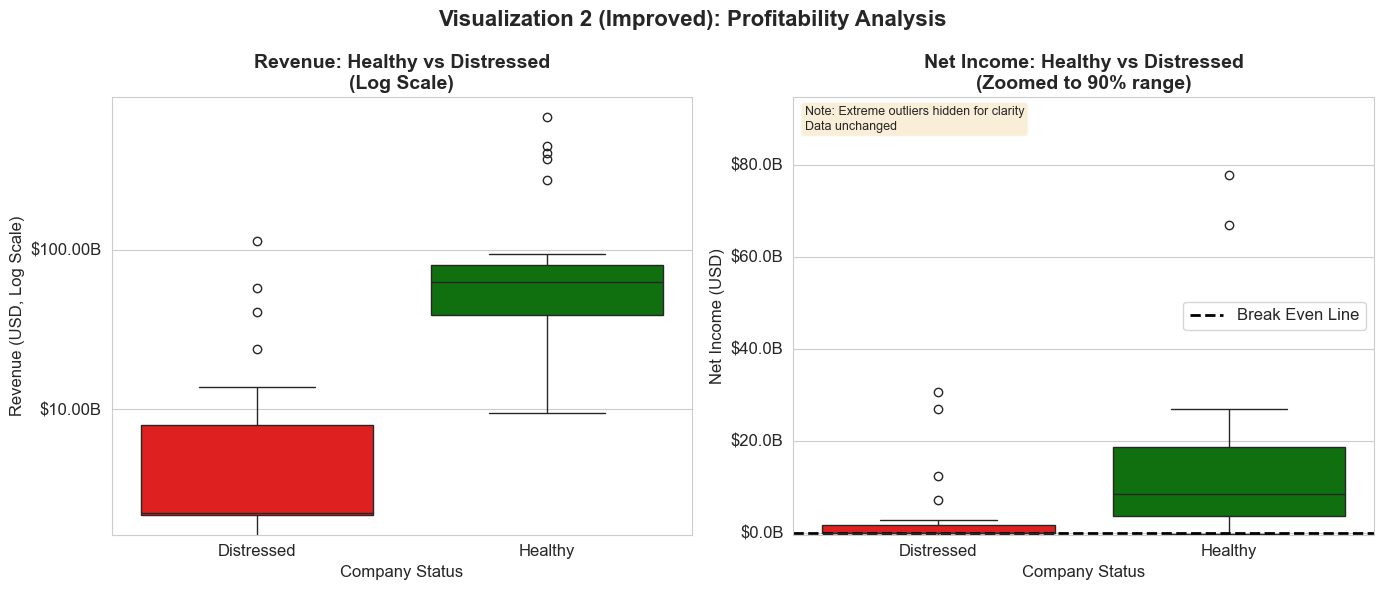

Improved Chart 2 saved!


In [12]:
# Cell 10 — Visualization 2 Improved: Net Income Zoomed In
# We limit the y-axis to focus on where 90% of companies sit
# This removes the visual compression caused by extreme outliers

# First calculate the 5th and 95th percentile to find our zoom range
# This means we show the range that covers 90% of our data
lower = df_clean['NetIncomeLoss'].quantile(0.05)
upper = df_clean['NetIncomeLoss'].quantile(0.95)

print(f"Showing Net Income range: ${lower/1e9:.1f}B to ${upper/1e9:.1f}B")
print(f"This covers 90% of our companies")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Chart 1: Revenue (Log Scale) — same as before ──
sns.boxplot(
    data=df_clean,
    x='status',
    y='Revenues',
    palette={'Healthy': 'green', 'Distressed': 'red'},
    ax=axes[0]
)
axes[0].set_yscale('log')
axes[0].set_title('Revenue: Healthy vs Distressed\n(Log Scale)',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Company Status')
axes[0].set_ylabel('Revenue (USD, Log Scale)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1e9:.2f}B')
)

# ── Chart 2: Net Income ZOOMED IN ──
sns.boxplot(
    data=df_clean,
    x='status',
    y='NetIncomeLoss',
    palette={'Healthy': 'green', 'Distressed': 'red'},
    ax=axes[1]
)

# The break even line — companies below this are losing money
axes[1].axhline(y=0, color='black', linestyle='--',
                linewidth=2, label='Break Even Line')

# THIS is the key — we zoom in to the 90% range
# Outliers still exist in data, we just zoom the view
axes[1].set_ylim(lower * 1.2, upper * 1.2)

axes[1].set_title('Net Income: Healthy vs Distressed\n(Zoomed to 90% range)',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Company Status')
axes[1].set_ylabel('Net Income (USD)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1e9:.1f}B')
)
axes[1].legend()

# Add a note on the chart explaining the zoom
axes[1].text(0.02, 0.98, 'Note: Extreme outliers hidden for clarity\nData unchanged',
             transform=axes[1].transAxes,
             fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Visualization 2 (Improved): Profitability Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/viz2_profitability_improved.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Improved Chart 2 saved!")

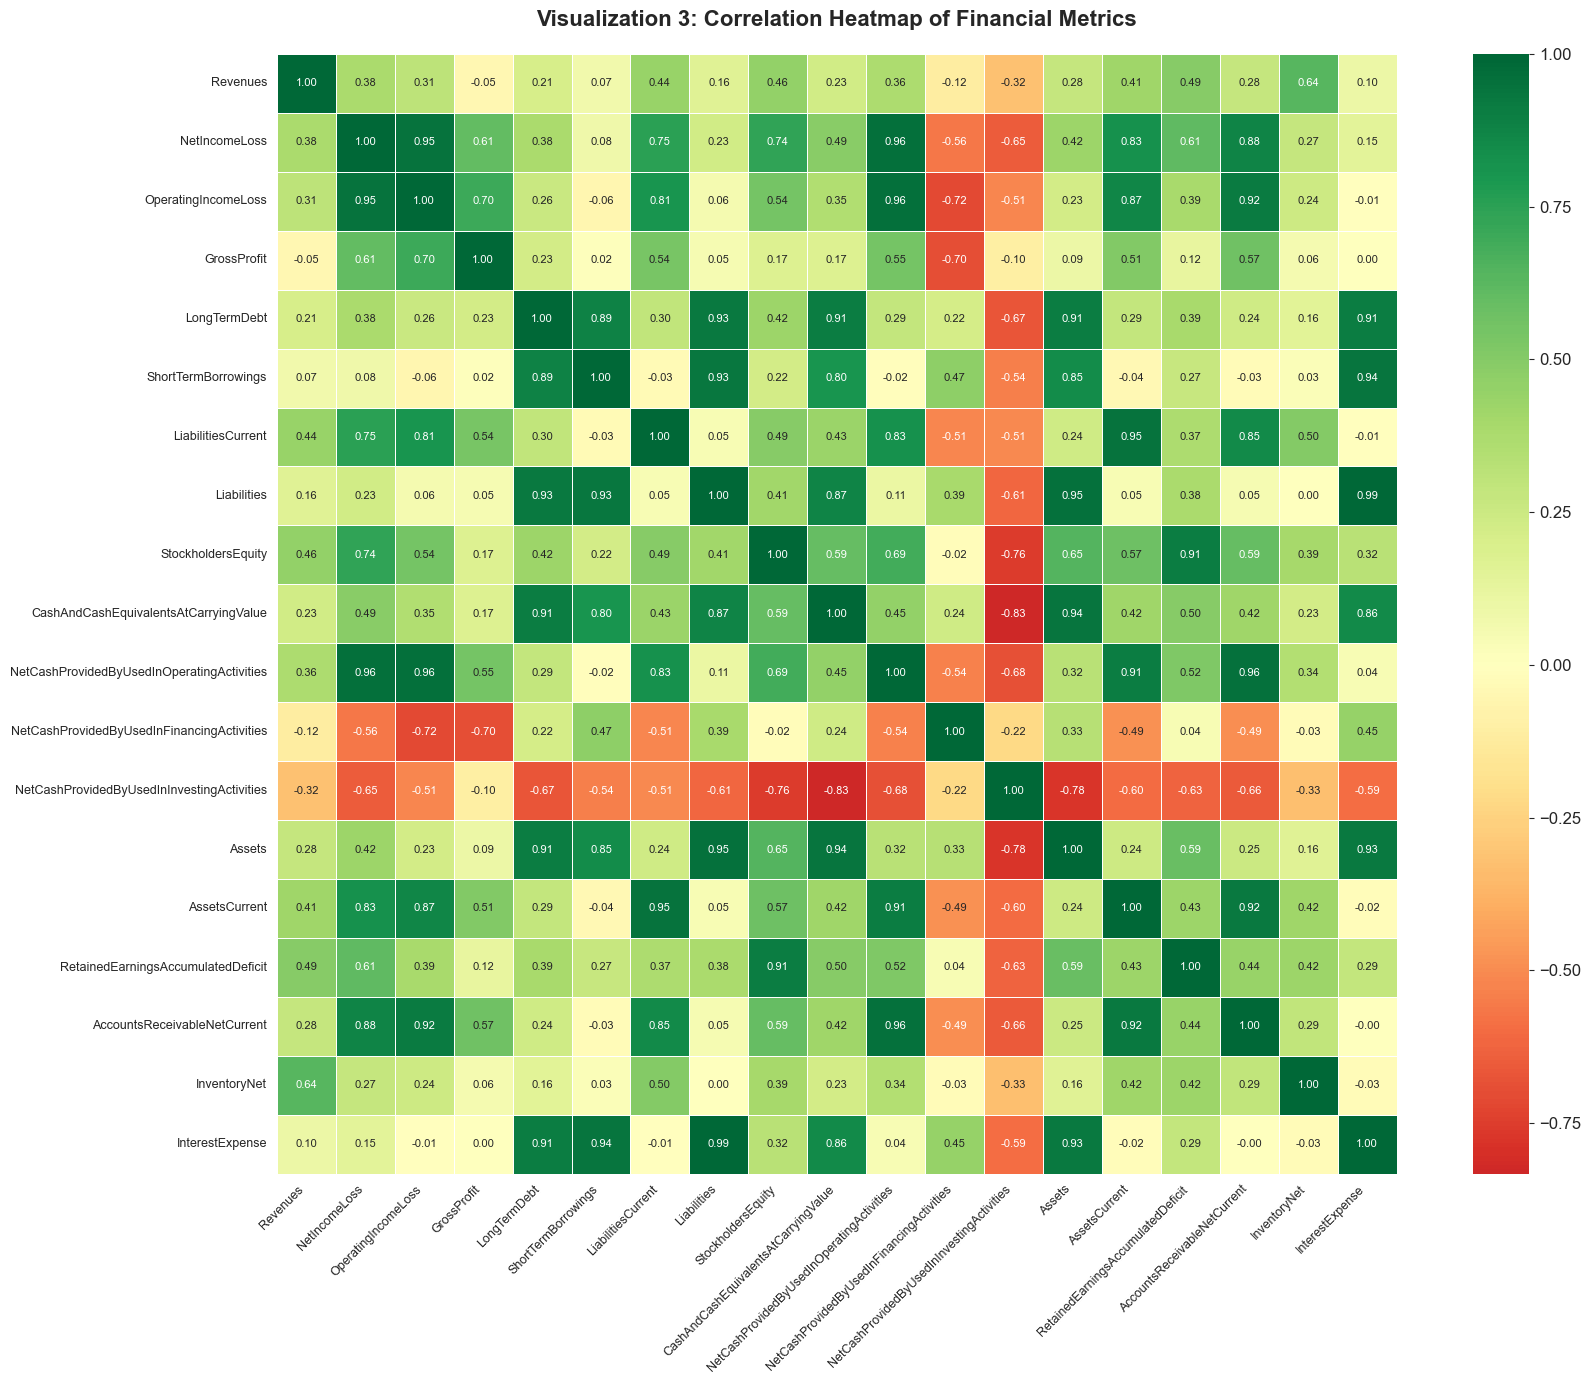

Chart 3 saved!


In [13]:
# Cell 11 — Visualization 3: Correlation Heatmap
# Shows which metrics are related to each other
# Helps us identify redundant features before ML modeling

# Select only the numeric financial columns — exclude company, label, status
numeric_cols = df_clean.drop(columns=['company', 'label', 'status'])

# Calculate correlation between all pairs of metrics
# corr() gives us a matrix of correlation values between -1 and +1
correlation_matrix = numeric_cols.corr()

# Create the heatmap
fig, ax = plt.subplots(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    annot=True,           # show the numbers inside each cell
    fmt='.2f',            # round to 2 decimal places
    cmap='RdYlGn',        # Red = negative, Yellow = neutral, Green = positive
    center=0,             # center the color scale at zero
    square=True,          # make each cell square shaped
    linewidths=0.5,       # add thin lines between cells
    annot_kws={'size': 8},# font size of the numbers
    ax=ax
)

ax.set_title('Visualization 3: Correlation Heatmap of Financial Metrics',
             fontsize=16, fontweight='bold', pad=20)

# Rotate labels for readability
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/viz3_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

## Findings: Visualization 3 — Correlation Heatmap

### Key Finding 1 — Size Cluster (High Redundancy)
Assets, Liabilities, LongTermDebt, and Cash are all highly correlated (0.91-0.95).
They all grow together simply because larger companies have more of everything.
Keeping all of them would give our ML model the same information multiple times.

Solution in Phase 4: Replace with size-normalized RATIOS:
- Debt-to-Assets ratio
- Cash-to-Liabilities ratio
- Current ratio (AssetsCurrent / LiabilitiesCurrent)

### Key Finding 2 — Profitability Cluster (High Redundancy)
NetIncomeLoss, OperatingIncomeLoss, and NetCashFromOperations correlate at 0.95-0.96.
These three metrics are essentially telling us the same thing.

Solution in Phase 4: Keep only Net Income Margin (NetIncome / Revenue)
as it captures profitability while removing size bias.

### Key Finding 3 — Investing Activities (Negative Signal)
NetCashFromInvesting is negatively correlated with almost everything.
This is expected — investing means cash goes OUT of the company.
Healthy companies invest heavily in growth (negative investing cash flow)
while distressed companies stop investing (cash flow closer to zero).
This is a strong and unique signal to keep.

### Key Finding 4 — Inventory (Independent Signal)
InventoryNet shows low correlation with most other metrics.
It behaves independently — specific to retail and manufacturing companies.
Many of our distressed companies are retailers (Toys R Us, Borders, RadioShack)
so inventory behavior may be a unique distress signal for this sector.

### Overall Conclusion
Our 19 raw metrics contain significant redundancy.
Phase 4 Feature Engineering will transform them into
clean, independent, size-normalized ratio features
that will give our ML model much stronger and cleaner signals.

## Visualization 4 — Distribution Overlap Analysis

### Question We Are Answering
How separable are healthy and distressed companies?
Where do the two groups overlap and where are they clearly different?

### Why This Matters
Before building any ML model we need to understand
how HARD our classification problem actually is.

If the two groups are completely separated — easy problem, any model will work.
If they overlap heavily — hard problem, we need a powerful model.

Think of it like this:
- Easy: All healthy companies have $10B+ cash, all distressed have less than $1B
- Hard: Both groups have companies with $1B-$5B cash — model must find other signals

### What is a KDE Plot?
KDE = Kernel Density Estimation
It shows the SHAPE of the distribution for each group as a smooth curve.

- Peak of the curve = where most companies cluster
- Width of the curve = how spread out the values are
- Overlap between curves = where classification is difficult

### What We Will Plot
We will check the 4 most important metrics:
- Cash (our strongest signal so far)
- NetIncomeLoss (profitability signal)
- LongTermDebt (solvency signal)
- NetCashFromOperations (cash flow signal)

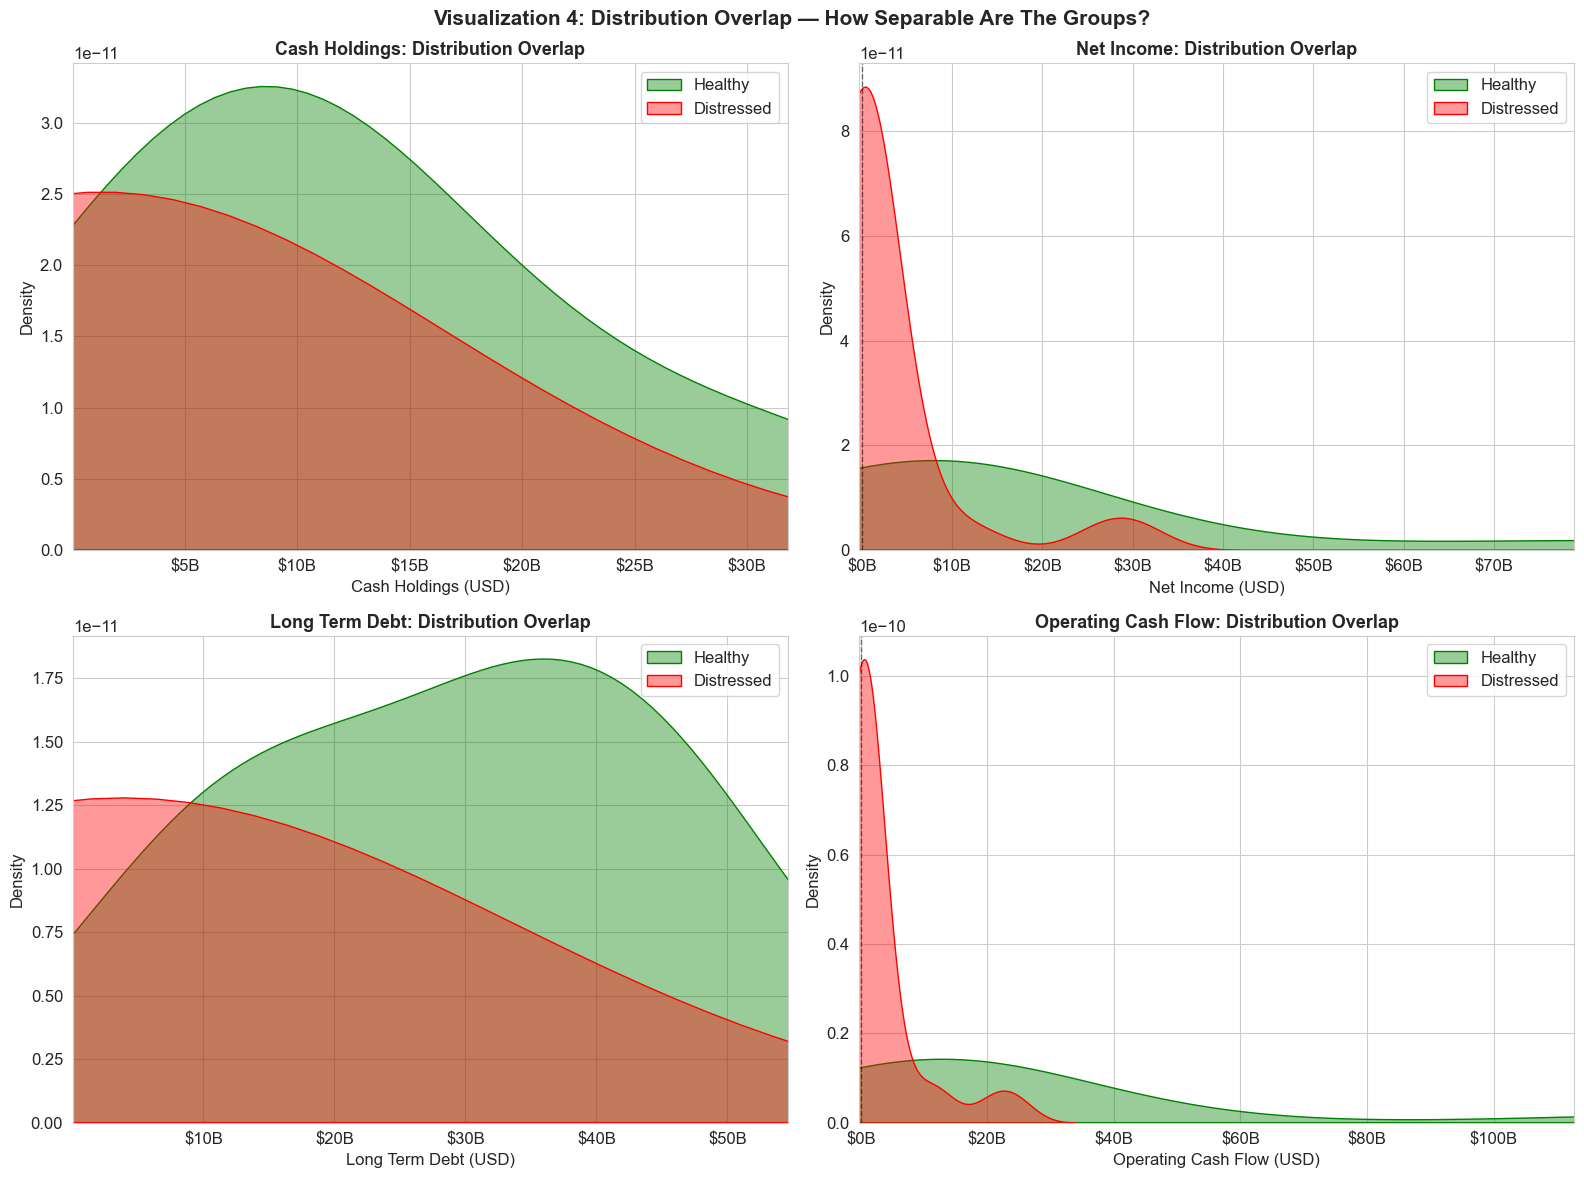

Chart 4 saved!


In [14]:
# Cell 12 — Visualization 4: Distribution Overlap Analysis
# KDE plots show the shape of each group's distribution
# Overlap between curves = where classification is difficult

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# 2 rows, 2 columns = 4 charts in one figure

# The 4 metrics we want to analyze
metrics = [
    ('CashAndCashEquivalentsAtCarryingValue', 'Cash Holdings', axes[0, 0]),
    ('NetIncomeLoss', 'Net Income', axes[0, 1]),
    ('LongTermDebt', 'Long Term Debt', axes[1, 0]),
    ('NetCashProvidedByUsedInOperatingActivities', 'Operating Cash Flow', axes[1, 1])
]

for metric, title, ax in metrics:

    # Separate healthy and distressed data for this metric
    healthy_data = df_clean[df_clean['status'] == 'Healthy'][metric]
    distressed_data = df_clean[df_clean['status'] == 'Distressed'][metric]

    # Plot KDE curve for each group
    # KDE = smooth curve showing distribution shape
    sns.kdeplot(
        data=healthy_data,
        ax=ax,
        color='green',
        fill=True,        # fill the area under the curve
        alpha=0.4,        # transparency so we can see overlap
        label='Healthy'
    )
    sns.kdeplot(
        data=distressed_data,
        ax=ax,
        color='red',
        fill=True,
        alpha=0.4,
        label='Distressed'
    )

    # Add a vertical line at zero for reference
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

    ax.set_title(f'{title}: Distribution Overlap',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{title} (USD)')
    ax.set_ylabel('Density')
    ax.legend()

    # Limit x axis to 95th percentile to remove extreme outliers visually
    upper = df_clean[metric].quantile(0.95)
    lower = df_clean[metric].quantile(0.05)
    ax.set_xlim(lower, upper)

    # Format x axis to billions
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'${x/1e9:.0f}B')
    )

plt.suptitle('Visualization 4: Distribution Overlap — How Separable Are The Groups?',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/viz4_distribution_overlap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

## Findings: Visualization 4 — Distribution Overlap Analysis

### Overall Assessment: Medium Difficulty Classification Problem
The two groups overlap significantly in raw metrics due to size bias.
This confirms that raw values alone will not be enough for our ML model.
Ratio features from Phase 4 will dramatically improve separability.

### Chart by Chart Findings

**Cash Holdings:**
- Heavy overlap between groups due to size bias
- Weak separator as a standalone raw metric
- Will become strong after normalization by total assets

**Net Income:**
- Distressed companies cluster sharply at zero
- Healthy companies spread wide to the right
- Good separation — net income margin will be even stronger

**Long Term Debt:**
- Heavy overlap — size bias dominates
- Raw debt alone cannot separate the groups
- Debt-to-Assets ratio will be much more informative

**Operating Cash Flow — STRONGEST SIGNAL:**
- Distressed companies cluster at zero — engine is dying
- Healthy companies generate strong positive cash flow
- Best raw metric separator we have found so far
- Confirms the slow suffocation pattern identified earlier

### Key Insight — The Slow Suffocation Pattern Confirmed
Distressed companies do not collapse suddenly.
They slowly stop generating cash from operations
while maintaining the appearance of a functioning business.
Operating cash flow captures this pattern earlier than any other metric.

This is analogous to volume divergence in trading analysis:
price looks stable on the surface but the underlying
flow of money tells a different story.

### Conclusion
Our ML model needs RATIO features to overcome size bias.
Operating Cash Flow will be one of our most important features.
Phase 4 will transform our raw metrics into powerful ratio signals.

## Visualization 5 — Operating Cash Flow Deep Dive

### Question We Are Answering
Is Operating Cash Flow truly our strongest early warning signal?
Can we see the difference between healthy and distressed companies
more clearly when we focus specifically on cash flow patterns?

### Why This Is Our Final EDA Visualization
From our previous 4 charts we consistently found that:
- Size bias dominates raw metrics
- Operating Cash Flow showed the clearest separation
- Distressed companies cluster at zero operating cash flow

Now we go deeper — we combine a box plot with individual
data points to see EVERY company's position, not just the distribution.

### Chart Type: Box Plot + Strip Plot Combined
- Box plot = shows the overall distribution
- Strip plot = shows every individual company as a dot
- Combined = we see both the pattern AND the individual cases

This is the most detailed view we can get without ratio features.
It will confirm whether operating cash flow deserves
to be our #1 feature in the ML model.

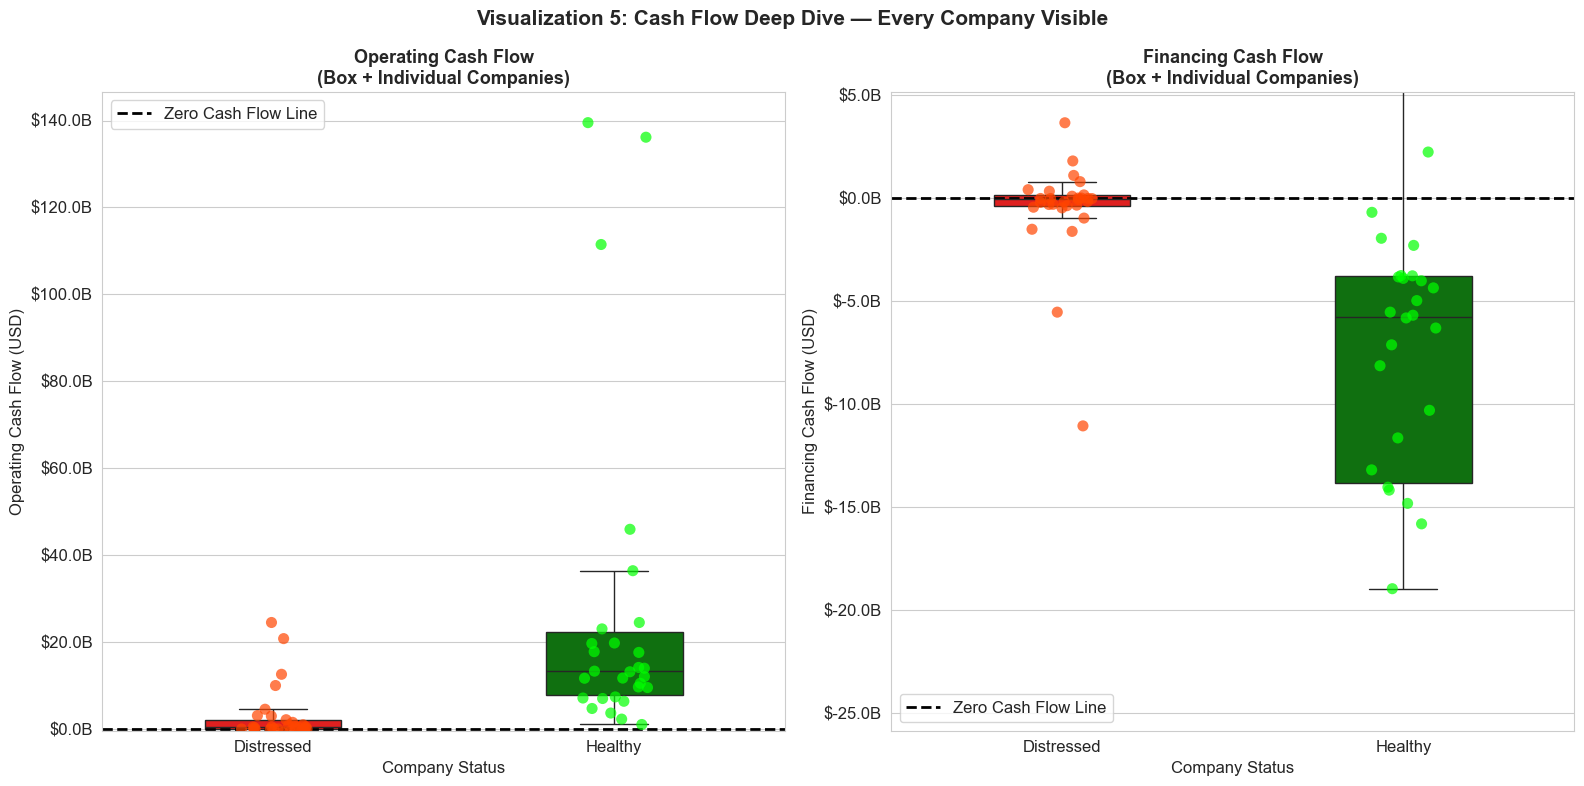

Chart 5 saved!


In [16]:
# Cell 13 — Visualization 5: Operating Cash Flow Deep Dive
# Box plot + Strip plot combined
# Strip plot shows every individual company as a dot
# This gives us the most detailed view of our strongest signal

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Chart 1: Operating Cash Flow — Box + Strip ──
# Box plot first — shows overall distribution
sns.boxplot(
    data=df_clean,
    x='status',
    y='NetCashProvidedByUsedInOperatingActivities',
    palette={'Healthy': 'green', 'Distressed': 'red'},
    ax=axes[0],
    width=0.4,
    flierprops=dict(marker='', alpha=0)  # hide default outlier dots
)

# Strip plot on top — shows every individual company
sns.stripplot(
    data=df_clean,
    x='status',
    y='NetCashProvidedByUsedInOperatingActivities',
    palette={'Healthy': '#00FF00', 'Distressed': '#FF4500'},    ax=axes[0],
    size=8,           # size of each dot
    alpha=0.7,        # transparency
    jitter=True       # spread dots horizontally so they don't overlap
)

# Add break even line
axes[0].axhline(y=0, color='black', linestyle='--',
                linewidth=2, label='Zero Cash Flow Line')

# Zoom to 95% range
upper = df_clean['NetCashProvidedByUsedInOperatingActivities'].quantile(0.95)
lower = df_clean['NetCashProvidedByUsedInOperatingActivities'].quantile(0.05)
axes[0].set_ylim(lower * 1.3, upper * 1.3)

axes[0].set_title('Operating Cash Flow\n(Box + Individual Companies)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Company Status')
axes[0].set_ylabel('Operating Cash Flow (USD)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1e9:.1f}B')
)
axes[0].legend()

# ── Chart 2: Financing Cash Flow — same approach ──
# Financing cash flow shows how companies raise or pay back money
# Distressed companies often raise desperate financing before collapse
sns.boxplot(
    data=df_clean,
    x='status',
    y='NetCashProvidedByUsedInFinancingActivities',
    palette={'Healthy': 'green', 'Distressed': 'red'},
    ax=axes[1],
    width=0.4,
    flierprops=dict(marker='', alpha=0)
)
sns.stripplot(
    data=df_clean,
    x='status',
    y='NetCashProvidedByUsedInFinancingActivities',
    palette={'Healthy': '#00FF00', 'Distressed': '#FF4500'},    ax=axes[1],
    size=8,
    alpha=0.7,
    jitter=True
)

axes[1].axhline(y=0, color='black', linestyle='--',
                linewidth=2, label='Zero Cash Flow Line')

upper2 = df_clean['NetCashProvidedByUsedInFinancingActivities'].quantile(0.95)
lower2 = df_clean['NetCashProvidedByUsedInFinancingActivities'].quantile(0.05)
axes[1].set_ylim(lower2 * 1.3, upper2 * 1.3)

axes[1].set_title('Financing Cash Flow\n(Box + Individual Companies)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Company Status')
axes[1].set_ylabel('Financing Cash Flow (USD)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1e9:.1f}B')
)
axes[1].legend()

plt.suptitle('Visualization 5: Cash Flow Deep Dive — Every Company Visible',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/viz5_cashflow_deepdive.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

## Findings: Visualization 5 — Cash Flow Deep Dive

### Operating Cash Flow — Strongest Signal Confirmed
Every individual company is now visible as a dot.

Healthy companies: dots spread from $5B to $140B
Distressed companies: almost all dots cluster near $0

The separation is the clearest we have seen across all 5 visualizations.
Operating Cash Flow is confirmed as our #1 raw signal.

### Financing Cash Flow — Surprising But Logical Finding
Healthy companies show NEGATIVE financing cash flow.
This seems counterintuitive but makes perfect sense:

- Healthy companies buy back their own shares (cash goes out)
- Healthy companies pay dividends to shareholders (cash goes out)
- Healthy companies pay down debt from a position of strength

Distressed companies cluster near zero because:
- They cannot afford to return money to shareholders
- They struggle to raise new financing
- They are frozen — neither paying back nor raising new money

### Key Insight — Two Different Types of Negative Cash Flow
Not all negative cash flow is bad.
Negative FINANCING cash flow = company is strong enough to return money
Negative OPERATING cash flow = company cannot generate money from business

This distinction is critical for our ML model.
The combination of strong operating cash flow + negative financing cash flow
is actually a signature of a very healthy company.

### Phase 3 EDA Complete
All 5 visualizations confirm the same story:
- Raw metrics suffer from size bias
- Operating cash flow is our strongest signal
- Ratio features will dramatically improve model performance
- Phase 4 Feature Engineering is our next critical step